# Practica ESPI

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

uint16


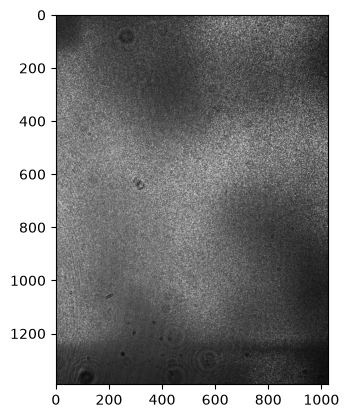

In [3]:
# metemos toodas las imagenes
ref1 = cv2.imread('Imagenes_ESPI/Sin sonido/pxfly_0007.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
print(ref1.dtype)
# Convertimos a float64
ref1 = np.float64(ref1)
plt.imshow(ref1, cmap='gray')

uint16


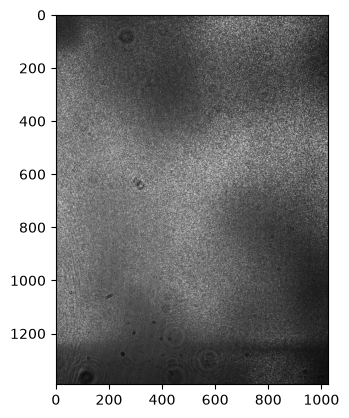

In [4]:
son1 = cv2.imread('Imagenes_ESPI/Con Sonido/pxfly_0001.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
print(son1.dtype)
son1 = np.float64(son1)
plt.imshow(son1, cmap='gray')

In [5]:
%load_ext autoreload
%autoreload 2

import sys
import os

# 2. Le decimos a Python que mire "una carpeta hacia atrás" (..) y entre a PCO_PixelFly
ruta_pco = os.path.abspath('../PCO_PixelFly')

if ruta_pco not in sys.path:
    sys.path.append(ruta_pco)
# Biblioteca propia
from procesamiento import filtros_en_frecuencia 
from procesamiento import operaciones_basicas


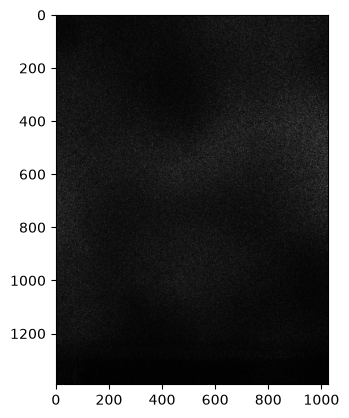

In [6]:
resta1 = operaciones_basicas.restar_consecutivas(ref1, son1)
plt.imshow(resta1, cmap='gray')

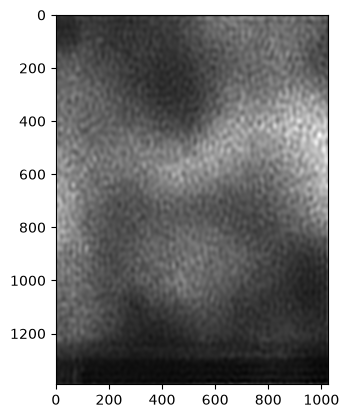

In [7]:
# Pasa bajas
Primero_filtrado = filtros_en_frecuencia.filtro_pasa_bajas_frecuencia(resta1, radio_corte=50)
plt.imshow(Primero_filtrado, cmap='gray')

In [8]:
# Imagenes sin sonido
sinson1 = cv2.imread('Imagenes_ESPI/Sin sonido/pxfly_0007.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
sinson1 = np.float64(sinson1)
sinson2 = cv2.imread('Imagenes_ESPI/Sin sonido/pxfly_0007.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
sinson2 = np.float64(sinson2)

In [9]:
# Imagenes con sonido
son1 = cv2.imread('Imagenes_ESPI/Con sonido/pxfly_0001.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
son1 = np.float64(son1)
son2 = cv2.imread('Imagenes_ESPI/Con sonido/pxfly_0002.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
son2 = np.float64(son2)
son3 = cv2.imread('Imagenes_ESPI/Con sonido/pxfly_0003.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
son3 = np.float64(son3)
son4 = cv2.imread('Imagenes_ESPI/Con sonido/pxfly_0002.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
son4 = np.float64(son4)

In [10]:
# Imagenes de referencia
ref2 = cv2.imread('Imagenes_ESPI/Referencia/pxfly_0010.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
ref2 = np.float64(ref2)
ref1 = cv2.imread('Imagenes_ESPI/Referencia/pxfly_0011.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
ref1 = np.float64(ref1)


In [11]:
# Imagenes del objeto
obj1 = cv2.imread('Imagenes_ESPI/Objeto/pxfly_0008.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
obj1 = np.float64(obj1)
obj2 = cv2.imread('Imagenes_ESPI/Objeto/pxfly_0009.tif', cv2.IMREAD_GRAYSCALE | cv2.IMREAD_ANYDEPTH)
obj2 = np.float64(obj2)

In [12]:
# Arreglo con todas las imagenes originales
Con_sonido = np.array([son1, son2, son3, son4])
Sin_sonido = np.array([sinson1, sinson2])
referencia = np.array([ref1, ref2])
objeto = np.array([obj1, obj2])

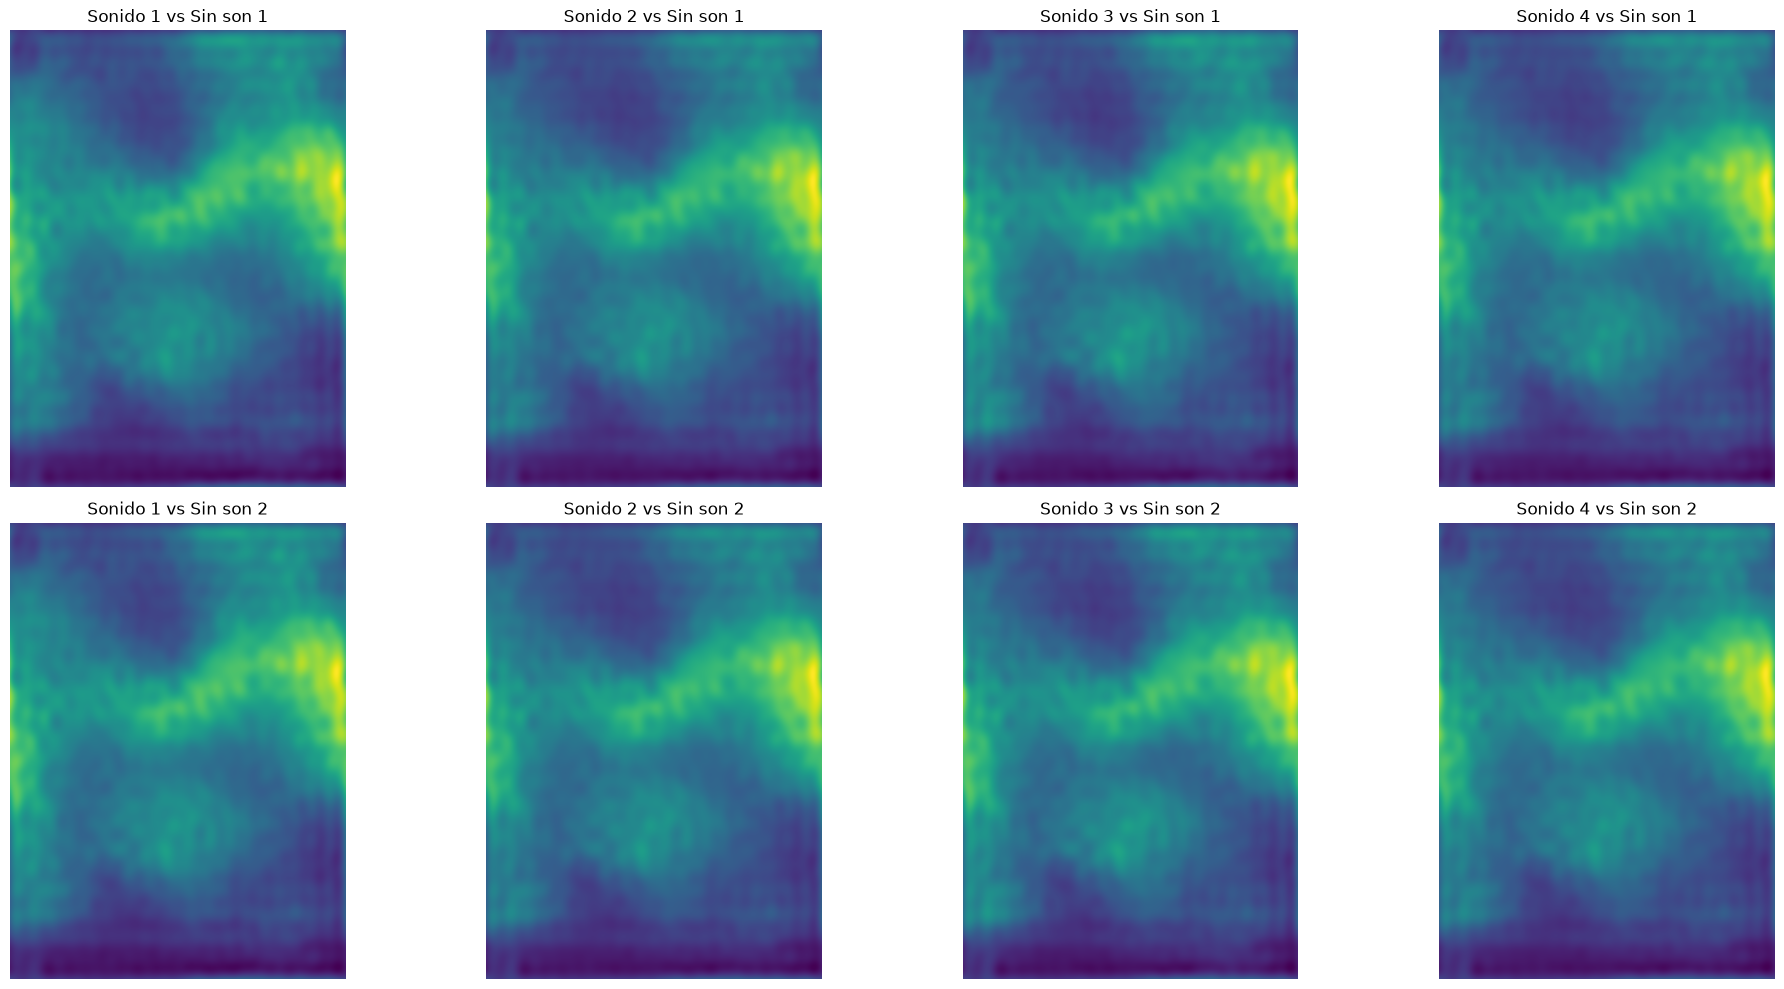

In [13]:
# radio de corte
r = 20

# Ploteado
fig, axes = plt.subplots(2, 4, figsize = (20, 10))
i , j = 0, 0
for sinj in Sin_sonido:
    for soni in Con_sonido:
        resta = operaciones_basicas.restar_consecutivas(soni, sinj)
        filtrada = filtros_en_frecuencia.filtro_pasa_bajas_frecuencia(resta, radio_corte=r)

        # Colocar la imagen en el subplot actual
        axes[j, i].imshow(filtrada, cmap='viridis') # Puedes usar cmap='gray' para blanco y negro
        
        # Opcional: Agregar un título a cada imagen
        axes[j, i].set_title(f'Sonido {i+1} vs Sin son {j+1}')
        
        # Opcional: Ocultar los ejes (líneas y números) para un aspecto más limpio
        axes[j, i].axis('off')
        i+=1
    j+=1
    i = 0

# Ajustar el espaciado automáticamente para que los títulos no se superpongan
plt.tight_layout()

# Mostrar la plantilla final
plt.show()

In [14]:
def I(xy, k, alpha, beta, h): 
    I_final = []
    return 2 * (1 + np.cos(2 * k * (alpha * xy + (np.pi / 2 - beta) * xy + h)))

[ WARN:0@876.009] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50495 (0xc53f) encountered
[ WARN:0@876.011] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50495 (0xc53f) encountered
[ WARN:0@876.013] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50495 (0xc53f) encountered
[ WARN:0@876.015] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50495 (0xc53f) encountered
[ WARN:0@876.017] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50495 (0xc53f) encountered
[ WARN:0@876.019] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50495 (0xc53f) encountered


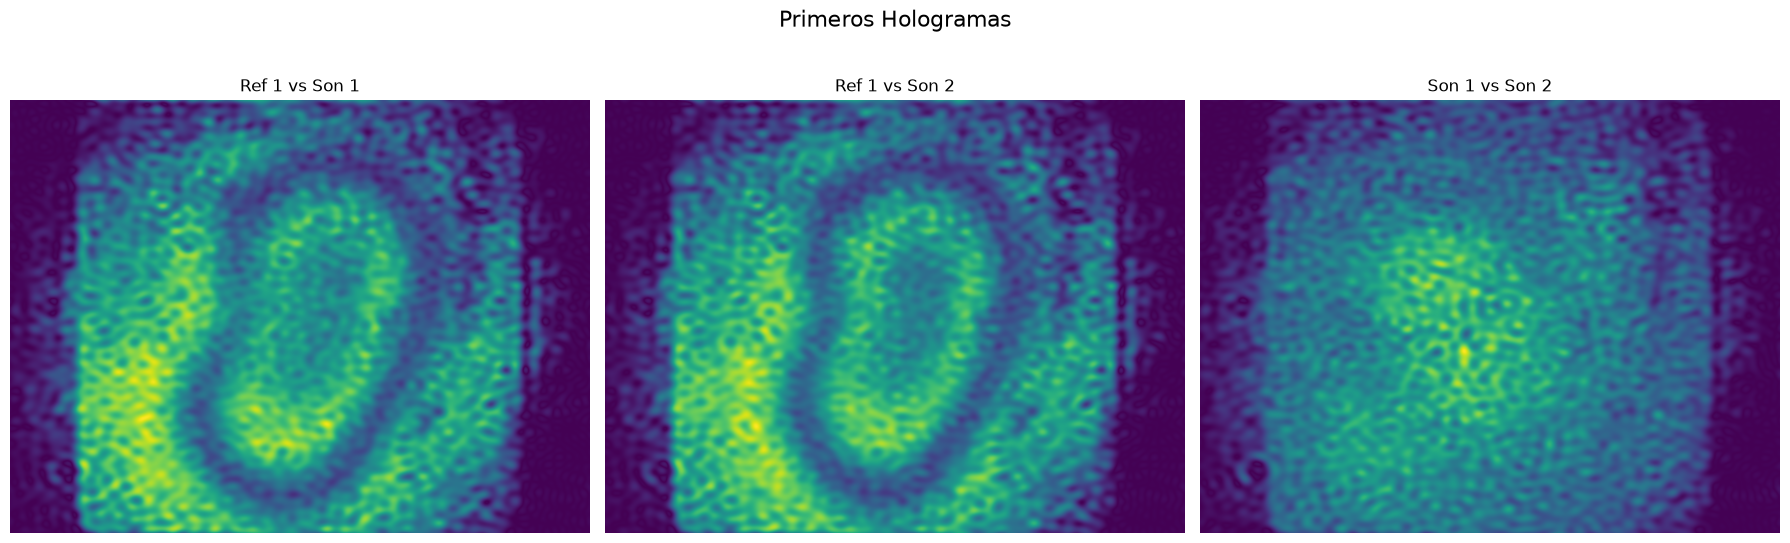

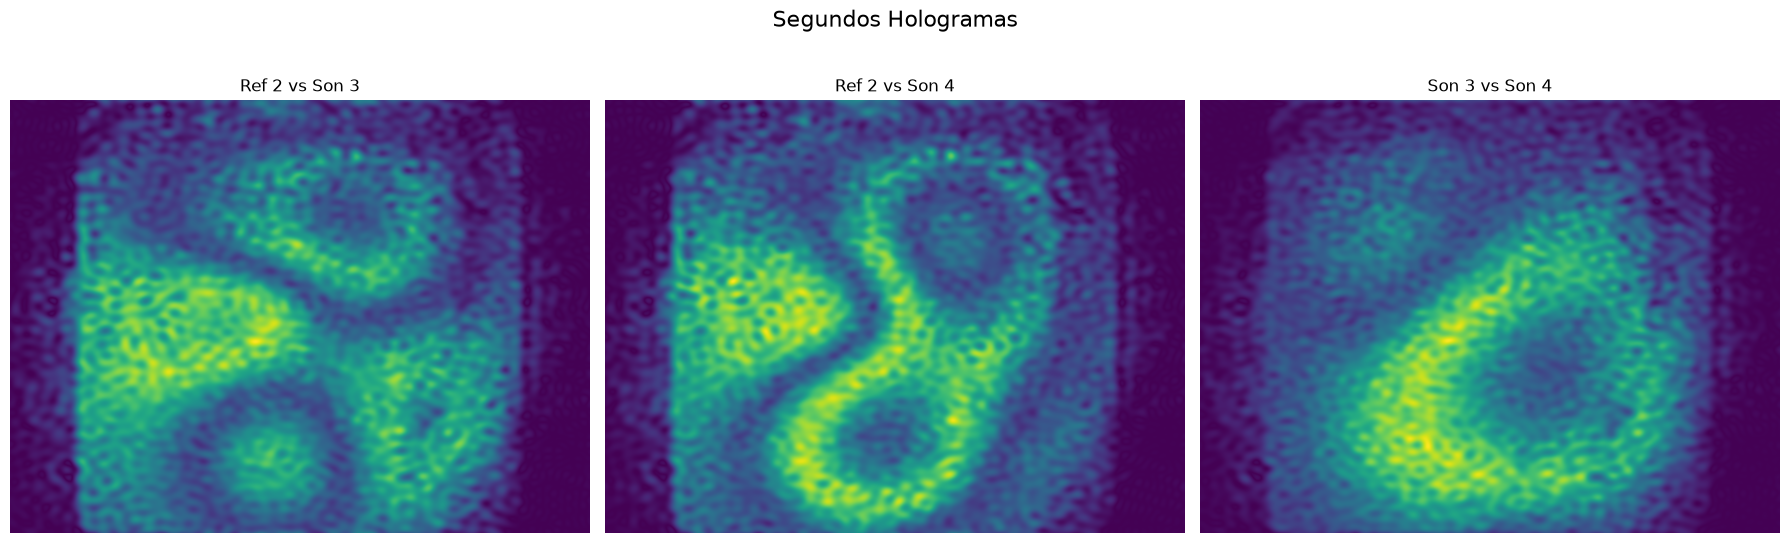

In [21]:
import cv2
import matplotlib.pyplot as plt
import os
# Asumiendo que ya tienes importados tus módulos:
# import operaciones_basicas
# import filtros_en_frecuencia

# Radio de corte
r = 40

# Rutas a las carpetas (ajusta si la ruta relativa es diferente en tu entorno)
ruta_P1 = "Hologramas_Dra/P1"
ruta_P2 = "Hologramas_Dra/P2"

# 1. Leer las imágenes de P1 en escala de grises
ref_P1 = cv2.imread(os.path.join(ruta_P1, "ref_0001.tif"), cv2.IMREAD_GRAYSCALE)
son_0004_P1 = cv2.imread(os.path.join(ruta_P1, "sonido_0004.tif"), cv2.IMREAD_GRAYSCALE)
son_0007_P1 = cv2.imread(os.path.join(ruta_P1, "sonido_0007.tif"), cv2.IMREAD_GRAYSCALE)

# 2. Leer las imágenes de P2 en escala de grises
ref_P2 = cv2.imread(os.path.join(ruta_P2, "ref_0001.tif"), cv2.IMREAD_GRAYSCALE)
son_0003_P2 = cv2.imread(os.path.join(ruta_P2, "sonido_0003.tif"), cv2.IMREAD_GRAYSCALE)
son_0009_P2 = cv2.imread(os.path.join(ruta_P2, "sonido_0009.tif"), cv2.IMREAD_GRAYSCALE)

# 3. Definir los pares de imágenes (Estado modificado, Estado de referencia, Título)
# Es importante el orden para la resta (sonido - referencia) o (sonido_B - sonido_A)
pares_P1 = [
    (son_0004_P1, ref_P1, 'Ref 1 vs Son 1'),
    (son_0007_P1, ref_P1, 'Ref 1 vs Son 2'),
    (son_0007_P1, son_0004_P1, 'Son 1 vs Son 2')
]

pares_P2 = [
    (son_0003_P2, ref_P2, 'Ref 2 vs Son 3'),
    (son_0009_P2, ref_P2, 'Ref 2 vs Son 4'),
    (son_0009_P2, son_0003_P2, 'Son 3 vs Son 4')
]

# --- Figura para P1 ---
fig_p1, axes_p1 = plt.subplots(1, 3, figsize=(18, 6))
fig_p1.suptitle('Primeros Hologramas', fontsize=16)

for idx, (img_estado, img_ref, titulo) in enumerate(pares_P1):
    # Obtener el estado diferencial de las dos imágenes
    resta = operaciones_basicas.restar_consecutivas(img_estado, img_ref)
    filtrada = filtros_en_frecuencia.filtro_pasa_bajas_frecuencia(resta, radio_corte=r)
    
    # Ploteado
    axes_p1[idx].imshow(filtrada, cmap='viridis') 
    axes_p1[idx].set_title(titulo)
    axes_p1[idx].axis('off')

plt.tight_layout()
plt.show()


# --- Figura para P2 ---
fig_p2, axes_p2 = plt.subplots(1, 3, figsize=(18, 6))
fig_p2.suptitle('Segundos Hologramas', fontsize=16)

for idx, (img_estado, img_ref, titulo) in enumerate(pares_P2):
    # Obtener el estado diferencial de las dos imágenes
    resta = operaciones_basicas.restar_consecutivas(img_estado, img_ref)
    filtrada = filtros_en_frecuencia.filtro_pasa_bajas_frecuencia(resta, radio_corte=r)
    
    # Ploteado
    axes_p2[idx].imshow(filtrada, cmap='viridis') 
    axes_p2[idx].set_title(titulo)
    axes_p2[idx].axis('off')

plt.tight_layout()
plt.show()